In [ ]:
wimport sys
import os

# Membungkus path dengan tanda kutip ganda untuk menangani spasi
python_path = f'"{sys.executable}"'
!{python_path} -m pip install tensorflo

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

# Konfigurasi Direktori (Sesuaikan dengan lokasi ekstraksi dataset Kaggle Anda)
base_dir = r"C:\Machine Learning\week_13\TrashType_Image_Dataset"

# Data Augmentation untuk mengatasi overfitting (Slide 8)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Membagi otomatis untuk data validasi
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Load Dataset
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [4]:
# Menggunakan VGG16 sebagai pre-trained model (Slide 8)
base_model = tf.keras.applications.VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# STRATEGI: Freeze pre-trained layers untuk mencegah overfitting (Slide 5, 6)
base_model.trainable = False

# Modifikasi bagian Classifier / Dense Layers (Slide 6, 69)
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Teknik tambahan penanganan overfitting
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Diubah ke nama loss yang benar
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


In [5]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.3048 - loss: 2.3119 - val_accuracy: 0.4712 - val_loss: 1.3623
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.3750 - loss: 1.4640 - val_accuracy: 0.6223 - val_loss: 1.1859
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.4333 - loss: 1.3426 - val_accuracy: 0.5567 - val_loss: 1.1188
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4437 - loss: 1.2913 - val_accuracy: 0.6581 - val_loss: 1.0612
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4723 - loss: 1.2632 - val_accuracy: 0.6680 - val_loss: 1.0333
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4531 - loss: 1.2337 - val_accuracy: 0.6342 - val_loss: 1.0864
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.4763 - loss: 1.2290 - val_accuracy: 0.6660 - val_loss: 1.0676
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5163 - loss: 1.1786 - val_accuracy: 0.6978 - v

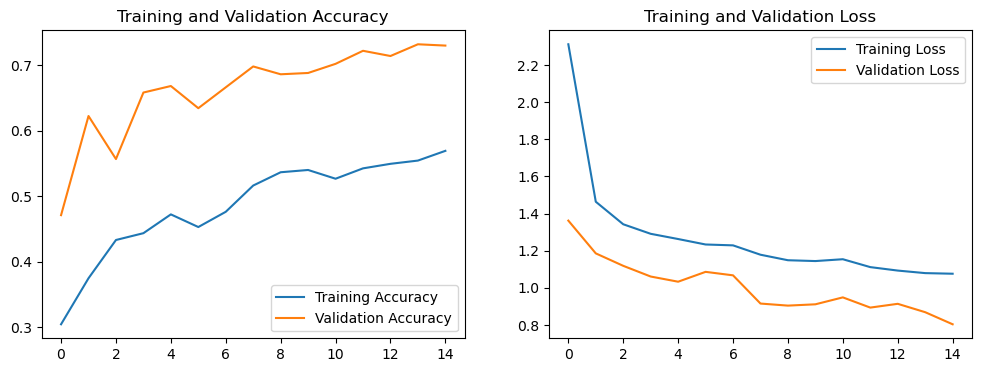

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### 1. Analisis Performa Model

Hasil pelatihan selama 15 epoch menunjukkan bahwa training accuracy meningkat dari 30,48% menjadi 56,92%, sedangkan validation accuracy meningkat dari 47,12% menjadi 72,96%. Selain itu, training loss dan validation loss terus menurun hingga masing-masing mencapai 1,0763 dan 0,8041. Hal ini menunjukkan bahwa model mampu mempelajari pola data dengan baik dan proses pelatihan berjalan secara stabil. Namun, karena kurva akurasi masih meningkat dan loss masih menurun pada epoch terakhir, model diperkirakan belum sepenuhnya konvergen sehingga performanya masih dapat ditingkatkan melalui penambahan epoch atau fine-tuning pada model VGG16.

### 2.Evaluasi Overfitting

Berdasarkan grafik akurasi dan loss, model tidak mengalami overfitting. Hal ini ditunjukkan oleh validation accuracy yang lebih tinggi daripada training accuracy, serta validation loss yang lebih rendah daripada training loss selama proses pelatihan. Kondisi ini disebabkan oleh penggunaan data augmentation pada data latih sehingga data menjadi lebih sulit dipelajari, serta penggunaan Dropout (0,5) yang hanya aktif saat proses training. Oleh karena itu, model memiliki kemampuan generalisasi yang cukup baik, meskipun masih terdapat peluang untuk meningkatkan performanya melalui fine-tuning atau penambahan jumlah epoch.